In [1]:
from google.colab import files
uploaded = files.upload()

Saving sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv to sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv


Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8103 - loss: 0.5214 - val_accuracy: 0.9603 - val_loss: 0.2048
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9401 - loss: 0.2402 - val_accuracy: 0.9603 - val_loss: 0.1686
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9401 - loss: 0.2291 - val_accuracy: 0.9603 - val_loss: 0.1692
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9401 - loss: 0.2330 - val_accuracy: 0.9603 - val_loss: 0.1692
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9401 - loss: 0.2322 - val_accuracy: 0.9603 - val_loss: 0.1696
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9401 - loss: 0.2316 - val_accuracy: 0.9603 - val_loss: 0.1691
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9401 - loss: 0.2322 - val_accuracy: 0.9603 - val_loss: 0.1696
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9401 - loss: 0.2309 - val_accuracy: 0.9603 - v

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:13:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



✅ Hybrid model Accuracy: 0.934
✅ Hybrid model F1 Score: 0.000

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       506
           1       0.00      0.00      0.00        28

    accuracy                           0.93       534
   macro avg       0.47      0.49      0.48       534
weighted avg       0.90      0.93      0.92       534



/tmp/ipython-input-8-3948772.py:82: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_flat, plot_type="bar")


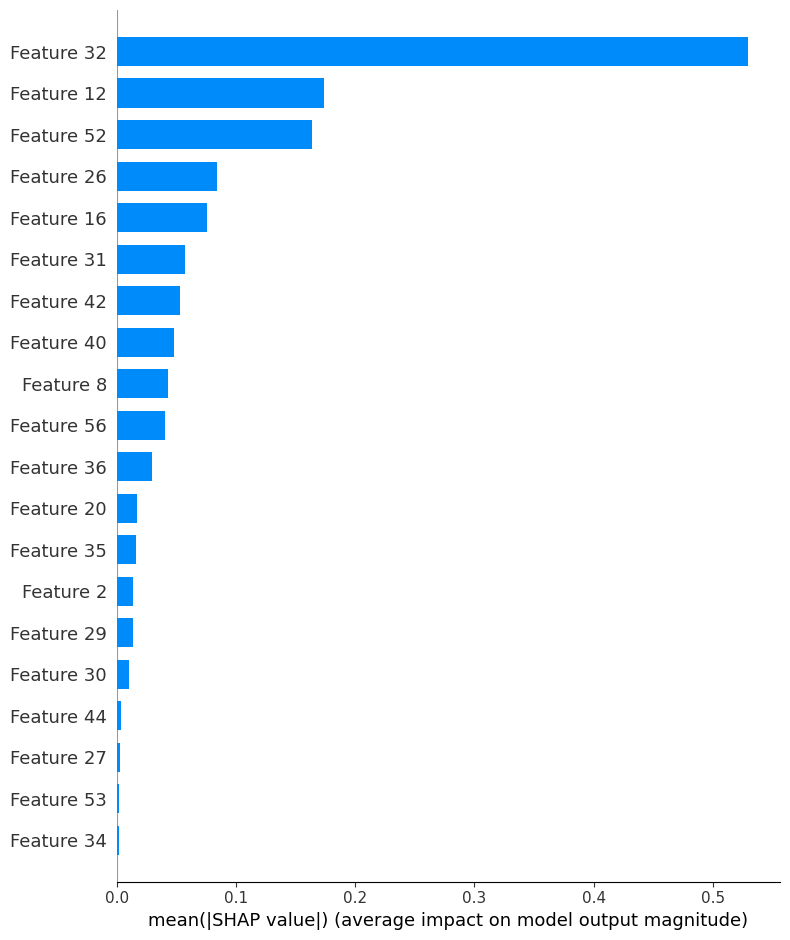

/tmp/ipython-input-8-3948772.py:85: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_flat)


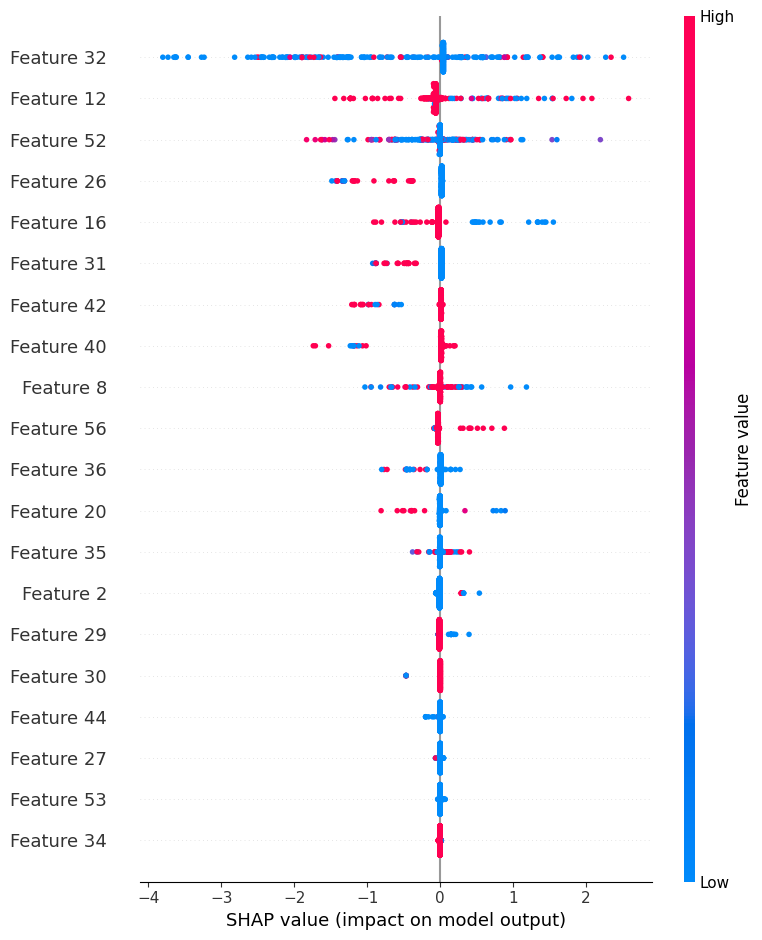

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('sovereign_default_dataset_1980_2022.csv - sovereign_default_dataset_1980_2022.csv')

# sequence preparation
sequence_length = 5
features = [col for col in df.columns if col not in ['Country', 'Year', 'Default']]
X_seq = []
y_labels = []

countries = df['Country'].unique()
for country in countries:
    country_df = df[df['Country'] == country].sort_values('Year')
    for i in range(len(country_df) - sequence_length):
        seq_X = country_df.iloc[i:i+sequence_length][features].values
        target_y = country_df.iloc[i+sequence_length]['Default']
        X_seq.append(seq_X)
        y_labels.append(target_y)

X_seq = np.array(X_seq)
y_labels = np.array(y_labels)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_labels, stratify=y_labels, test_size=0.2, random_state=42)

num_features = X_train.shape[2]

# using Functional API
inputs = Input(shape=(sequence_length, num_features))
x = LSTM(64, return_sequences=False)(inputs)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# TrainED LSTM model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Extract embeddings (output of LSTM layer)
embedding_model = Model(inputs=model.input, outputs=model.layers[1].output)
X_train_embed = embedding_model.predict(X_train)
X_test_embed = embedding_model.predict(X_test)

# Flatten embeddings for XGBoost
X_train_flat = X_train_embed.reshape(X_train_embed.shape[0], -1)
X_test_flat = X_test_embed.reshape(X_test_embed.shape[0], -1)

# Train XGBoost on embeddings
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train_flat, y_train)

# Evaluate hybrid model
y_pred = xgb_model.predict(X_test_flat)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n✅ Hybrid model Accuracy: {acc:.3f}")
print(f"✅ Hybrid model F1 Score: {f1:.3f}")
print("\nClassification report:\n", classification_report(y_test, y_pred))

# SHAP interpretability for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_flat)

# Summary plot (global feature importance)
shap.summary_plot(shap_values, X_test_flat, plot_type="bar")

# Beeswarm plot (detailed distribution)
shap.summary_plot(shap_values, X_test_flat)
